Análise dos Microdados do ENEM – Goiás

Disciplina: CESAR  
Curso:Ciência de Dados / IA  
Instituição: UNISO  

Este notebook apresenta uma análise exploratória dos microdados do ENEM,
com foco nos participantes do estado de Goiás.


# Importação de bibliotecas

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Carregamento dos dados

In [39]:
df_go_resultados = df_resultados[df_resultados["SG_UF_PROVA"] == "GO"]
df_go_participantes = df_participantes[df_participantes["SG_UF_PROVA"] == "GO"]

# Visão inicial

Não tratada

In [40]:
import pandas as pd

df_resultados = pd.read_csv(
    "../dados/bruto/RESULTADOS_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_participantes = pd.read_csv(
    "../dados/bruto/PARTICIPANTES_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_resultados.shape, df_participantes.shape


((4332944, 42), (4332944, 38))

# Limpeza e Tratamento

Selecionar apenas colunas necessárias

In [ ]:
coluna_notas = [
    "SG_UF_PROVA",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_CH",
    "NU_NOTA_CN",
    "NU_NOTA_REDACAO",
]

df = df_resultados[coluna_notas].copy()
print ("Base Inicial:", df.shape)

Base Inicial: (4332944, 6)


Colocando nomes legíveis

In [ ]:
df = df.rename(columns={
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
})

print("Colunas renomeadas:")
print(df.columns)

Colunas renomeadas:
Index(['SG_UF_PROVA', 'Linguagens', 'Matemática', 'Ciências Humanas',
       'Ciências da Natureza', 'Redação'],
      dtype='str')


Remoção de registros duplicados

In [ ]:
duplicados = df.duplicated().sum()
print("Quantidade de registros duplicados:", duplicados)
df = df.drop_duplicates ()
print ("Base apóes remover duplicados:", df.shape)

Quantidade de registros duplicados: 1151156
Base apóes remover duplicados: (3181788, 6)


Remoção de ausentes

In [ ]:
print("\nValores nulos antes da remoção:")
print(df.isnull().sum())

df = df.dropna(subset=[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
])

print("\nValores nulos após remoção:")
print(df.isnull().sum())

print("Base após remover NaN:", df.shape)


Valores nulos antes da remoção:
SG_UF_PROVA                  0
Linguagens               14842
Matemática              176888
Ciências Humanas         14842
Ciências da Natureza    176888
Redação                  14842
dtype: int64

Valores nulos após remoção:
SG_UF_PROVA             0
Linguagens              0
Matemática              0
Ciências Humanas        0
Ciências da Natureza    0
Redação                 0
dtype: int64
Base após remover NaN: (2990085, 6)


Garantir intervalo das notas (0 a 1000)

In [ ]:
colunas_notas_numericas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação",
]

for col in colunas_notas_numericas:
    df = df[(df[col] >= 0) & (df[col] <= 1000)]
print("Base após validar o intervalo das notas:", df.shape)

Base após validar o intervalo das notas: (2990085, 6)


Conferindo limpeza

In [ ]:
print("\nResumo estatístico após limpeza:")
print(df.describe())

print("\nLimpeza concluída.")


Resumo estatístico após limpeza:
         Linguagens    Matemática  Ciências Humanas  Ciências da Natureza  \
count  2.990085e+06  2.990085e+06      2.990085e+06          2.990085e+06   
mean   5.266230e+02  5.270825e+02      5.142141e+02          4.940272e+02   
std    6.865276e+01  1.141688e+02      9.155267e+01          7.898593e+01   
min    0.000000e+00  0.000000e+00      0.000000e+00          0.000000e+00   
25%    4.867000e+02  4.313000e+02      4.502000e+02          4.315000e+02   
50%    5.334000e+02  4.992000e+02      5.194000e+02          4.885000e+02   
75%    5.736000e+02  6.110000e+02      5.785000e+02          5.503000e+02   
max    7.958000e+02  9.619000e+02      8.197000e+02          8.672000e+02   

            Redação  
count  2.990085e+06  
mean   6.346677e+02  
std    2.090931e+02  
min    0.000000e+00  
25%    5.200000e+02  
50%    6.400000e+02  
75%    8.000000e+02  
max    1.000000e+03  

Limpeza concluída.


# 3. Análise Comparativa — Goiás vs Brasil

Nesta seção, comparamos o desempenho médio dos participantes do ENEM 2024
do estado de Goiás (GO) com a média nacional (Brasil),
considerando as cinco áreas avaliadas.

Garantindo dados limpos

In [ ]:
colunas_notas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]

df_limpo = df.dropna(subset=colunas_notas)

In [ ]:
print(df.columns)

Index(['SG_UF_PROVA', 'Linguagens', 'Matemática', 'Ciências Humanas',
       'Ciências da Natureza', 'Redação'],
      dtype='str')


Separar Go do Brasil

In [ ]:
df_go = df[df["SG_UF_PROVA"] == "GO"]
df_br = df  # Brasil inteiro

tamanho dos dados

In [ ]:
print("Tamanho GO:", df_go.shape)
print("Tamanho Brasil:", df_br.shape)

Tamanho GO: (102473, 6)
Tamanho Brasil: (2990085, 6)


calculo das médias

In [46]:
colunas_notas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]

media_go = df_go_resultados[colunas_notas].mean()
media_br = df_resultados[colunas_notas].mean()

medias = pd.DataFrame({
    "GO": media_go,
    "Brasil": media_br
}).round(2)

medias

,GO,Brasil
Linguagens,522.36,524.47
Matemática,527.41,526.97
Ciências Humanas,509.19,511.01
Ciências da Natureza,494.59,493.93
Redação,647.71,624.59


Desvio padrão das notas

In [ ]:
desvio_go = df_go[colunas_notas].std()
desvio_br = df_br[colunas_notas].std()

df_desvios = pd.DataFrame({
    "Desvio_GO": desvio_go,
    "Desvio_BR": desvio_br
})

df_desvios.round(2)

,Desvio_GO,Desvio_BR
Linguagens,66.60,68.65
Matemática,113.11,114.17
Ciências Humanas,89.76,91.55
Ciências da Natureza,78.85,78.99
Redação,200.86,209.09


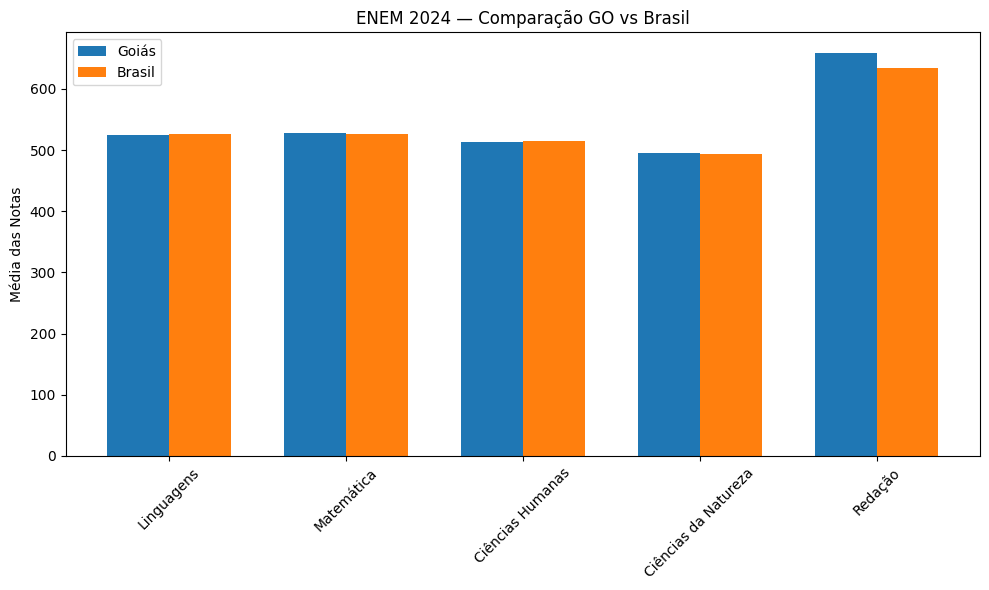

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

disciplinas = df_medias.index
x = np.arange(len(disciplinas))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - width/2, df_medias["Média_GO"], width, label='Goiás')
ax.bar(x + width/2, df_medias["Média_BR"], width, label='Brasil')

ax.set_ylabel('Média das Notas')
ax.set_title('ENEM 2024 — Comparação GO vs Brasil')
ax.set_xticks(x)
ax.set_xticklabels(disciplinas)
ax.legend()


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(df_resultados.columns)

Index(['NU_SEQUENCIAL', 'NU_ANO', 'CO_ESCOLA', 'CO_MUNICIPIO_ESC',
       'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',
       'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'CO_MUNICIPIO_PROVA',
       'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'TP_PRESENCA_CN',
       'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'CO_PROVA_CN',
       'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH',
       'NU_NOTA_LC', 'NU_NOTA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH',
       'TX_RESPOSTAS_LC', 'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TX_GABARITO_CN',
       'TX_GABARITO_CH', 'TX_GABARITO_LC', 'TX_GABARITO_MT',
       'TP_STATUS_REDACAO', 'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3',
       'NU_NOTA_COMP4', 'NU_NOTA_COMP5', 'NU_NOTA_REDACAO'],
      dtype='str')


In [ ]:
print(df_participantes.columns)

Index(['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO',
       'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO',
       'TP_ANO_CONCLUIU', 'TP_ENSINO', 'IN_TREINEIRO', 'CO_MUNICIPIO_PROVA',
       'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'Q001', 'Q002',
       'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011',
       'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020',
       'Q021', 'Q022', 'Q023'],
      dtype='str')


# Análise de renda — GO vs Brasil
### Distribuição de renda familiar dos participantes

Nesta seção analisamos a distribuição das faixas de renda familiar dos participantes
do ENEM 2024, comparando o estado de Goiás com o conjunto nacional.

In [ ]:
# Filtrar participantes de Goiás
df_part_go = df_participantes[df_participantes["SG_UF_PROVA"] == "GO"]

# Distribuição percentual de renda no Brasil
renda_br = df_participantes["Q006"].value_counts(normalize=True).sort_index() * 100

# Distribuição percentual de renda em Goiás
renda_go = df_part_go["Q006"].value_counts(normalize=True).sort_index() * 100

# Criar tabela comparativa
comparacao_renda = pd.DataFrame({
    "GO_%": renda_go,
    "BR_%": renda_br
}).fillna(0)

comparacao_renda.round(2)

,GO_%,BR_%
Q006,,
A,70.74,72.45
B,29.26,27.55


In [ ]:
mapa_renda = {
    "A": "Baixa renda",
    "B": "Renda um pouco maior"
}

comparacao_renda.index = comparacao_renda.index.map(mapa_renda)
comparacao_renda

,GO_%,BR_%
Q006,,
Baixa renda,70.737242,72.446021
Renda um pouco maior,29.262758,27.553979


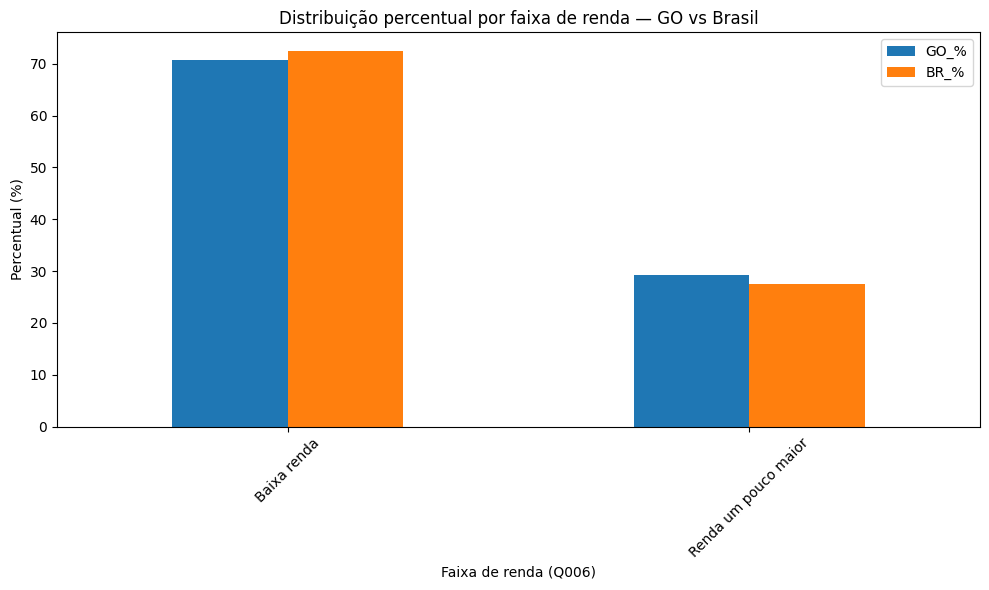

In [ ]:
import matplotlib.pyplot as plt

comparacao_renda.plot(kind="bar", figsize=(10,6))

plt.title("Distribuição percentual por faixa de renda — GO vs Brasil")
plt.ylabel("Percentual (%)")
plt.xlabel("Faixa de renda (Q006)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Resumo - A análise da variável renda familiar mostra que a maioria dos participantes do ENEM pertence às faixas de menor renda. Em Goiás, aproximadamente 70,74% dos participantes estão na categoria A, enquanto no Brasil esse percentual é de 72,45%. A categoria B representa 29,26% dos participantes em Goiás e 27,55% no Brasil. Esses resultados indicam que o perfil socioeconômico dos participantes do estado é bastante semelhante ao observado no cenário nacional, com predominância de candidatos provenientes de famílias de menor renda.

A predominância de participantes nas faixas de menor renda reforça o papel do ENEM como principal porta de entrada para o ensino superior público no Brasil, especialmente para estudantes provenientes de contextos socioeconômicos menos favorecidos.

# Análise por raça — GO vs Brasil
### Distribuição por raça/cor

Também analisamos a distribuição de raça/cor declarada pelos participantes
do ENEM, comparando o estado de Goiás com a distribuição nacional.

In [ ]:
# Distribuição percentual no Brasil
raca_br = df_participantes["TP_COR_RACA"].value_counts(normalize=True).sort_index() * 100

# Distribuição percentual em Goiás
raca_go = df_part_go["TP_COR_RACA"].value_counts(normalize=True).sort_index() * 100

# Criar tabela comparativa
comparacao_raca = pd.DataFrame({
    "GO_%": raca_go,
    "BR_%": raca_br
}).fillna(0)

comparacao_raca.round(2)

,GO_%,BR_%
TP_COR_RACA,,
0,1.49,1.17
1,38.74,41.35
2,11.25,12.34
3,45.92,43.01
4,2.18,1.44
5,0.42,0.69


In [ ]:
mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena",
    6: "Não informado"
}

comparacao_raca.index = comparacao_raca.index.map(mapa_raca)

comparacao_raca

,GO_%,BR_%
TP_COR_RACA,,
Não declarado,1.490493,1.168536
Branca,38.738935,41.354885
Preta,11.246510,12.339255
Parda,45.924794,43.006256
Amarela,2.179177,1.440568
Indígena,0.420090,0.690501


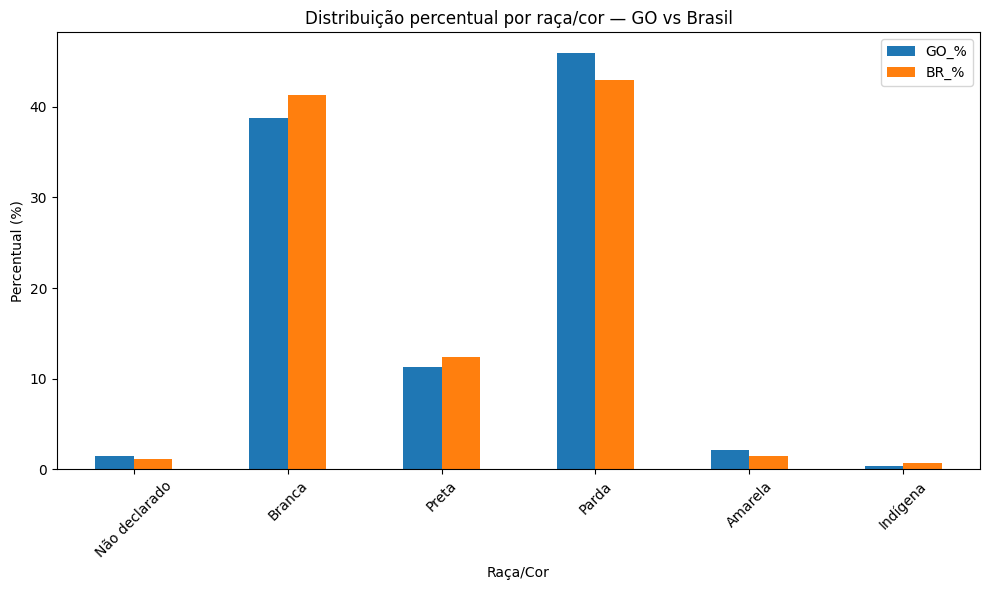

In [ ]:
comparacao_raca.plot(kind="bar", figsize=(10,6))

plt.title("Distribuição percentual por raça/cor — GO vs Brasil")
plt.ylabel("Percentual (%)")
plt.xlabel("Raça/Cor")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Resumindo - A análise da variável raça/cor indica que a maioria dos participantes do ENEM pertence às categorias parda e branca, tanto em Goiás quanto no Brasil. Em Goiás, os participantes pardos representam aproximadamente 45,9%, enquanto os brancos correspondem a 38,7%. No cenário nacional, esses valores são 43,0% e 41,3%, respectivamente. As demais categorias apresentam menor participação, com destaque para os participantes pretos, que representam cerca de 11% em Goiás e 12% no Brasil. De modo geral, observa-se que a distribuição racial dos participantes em Goiás segue um padrão semelhante ao observado nacionalmente, com pequenas diferenças percentuais entre os grupos.

In [43]:
df_resultados = df_resultados.rename(columns={
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
})

Histograma das notas

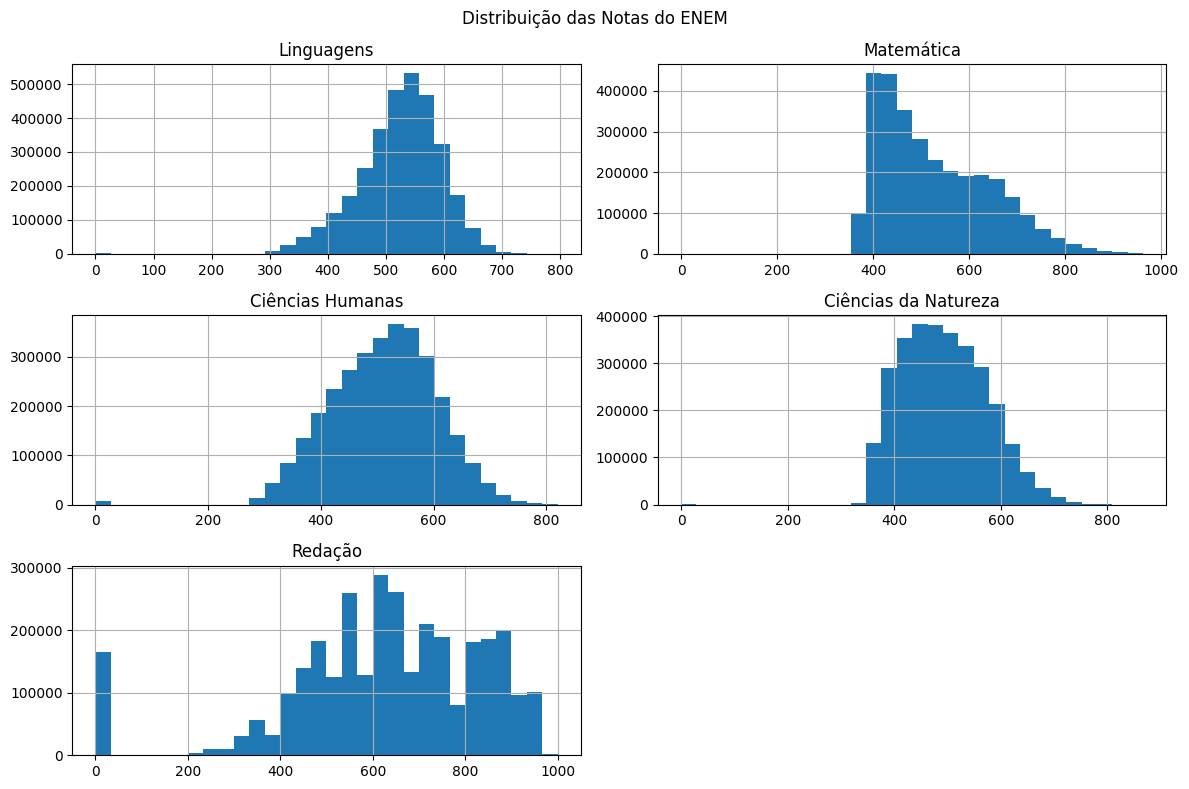

In [44]:
import matplotlib.pyplot as plt

df_resultados[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].hist(bins=30, figsize=(12,8))

plt.suptitle("Distribuição das Notas do ENEM")
plt.tight_layout()
plt.show()

Matriz de correlação das notas

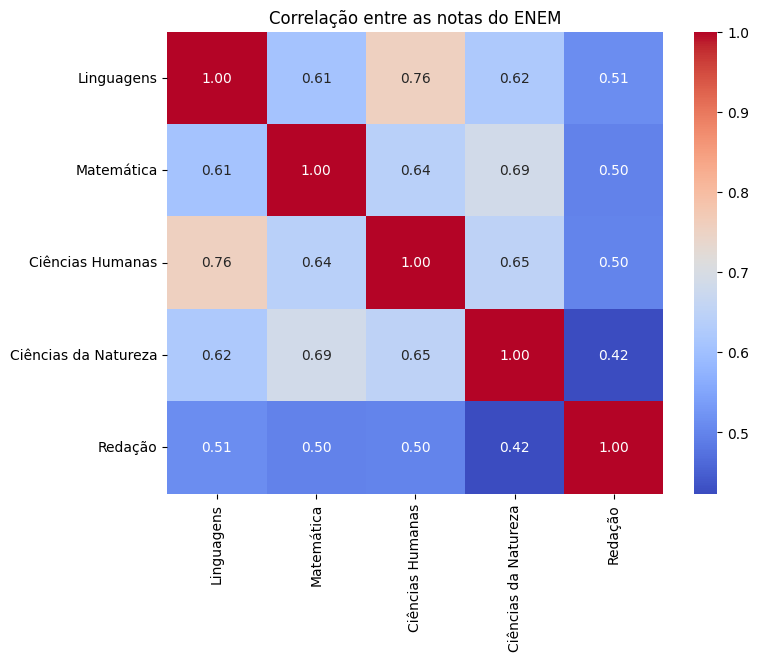

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_resultados[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlação entre as notas do ENEM")
plt.show()

In [ ]:
mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena"
}

In [ ]:
df_participantes["RACA"] = df_participantes["TP_COR_RACA"].map(mapa_raca)

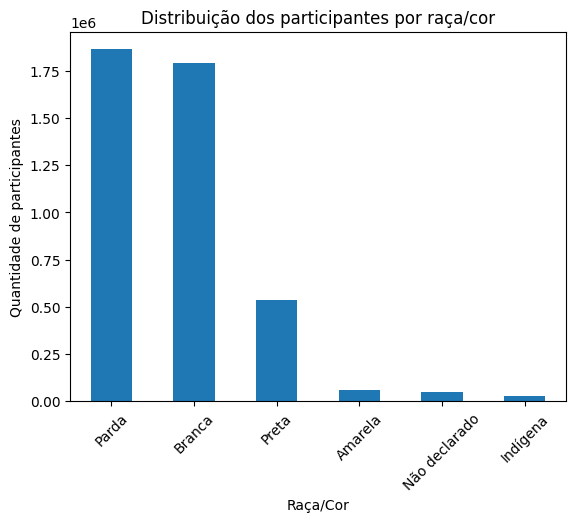

In [ ]:
import matplotlib.pyplot as plt

df_participantes["RACA"].value_counts().plot(kind="bar")

plt.title("Distribuição dos participantes por raça/cor")
plt.xlabel("Raça/Cor")
plt.ylabel("Quantidade de participantes")

plt.xticks(rotation=45)

plt.show()

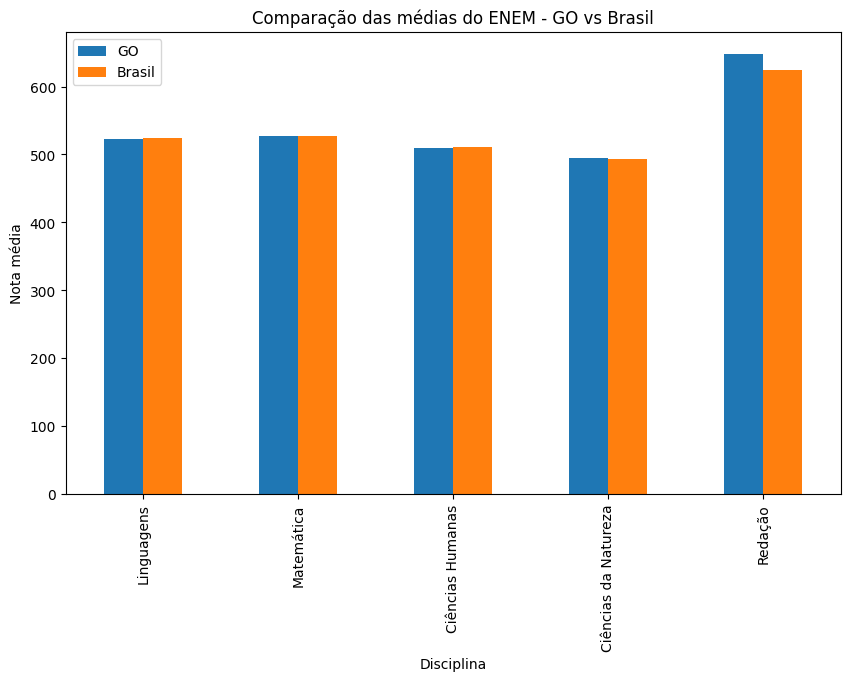

In [47]:
medias.plot(kind="bar", figsize=(10,6))

plt.title("Comparação das médias do ENEM - GO vs Brasil")
plt.ylabel("Nota média")
plt.xlabel("Disciplina")

plt.show()